In [59]:
!rm -rf data.zip data/ sample_data

In [60]:
!pip install torch_geometric

In [61]:
# ---- Hyperparameters ----
EPOCHS = 5
BATCH_SIZE = 32
LEARNING_RATE = 0.001
EMBEDDING_DIM = 64
HIDDEN_DIM = 128
SPLIT_RATIO = 0.8

In [62]:
# ---- Imports ----
import os
import zipfile
import requests
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.data import Data, Batch
from tqdm import tqdm

In [63]:
# ---- Download and extract data ----
if os.path.exists("data"):
    print("Data directory already exists, skipping download and extraction.")
else:
    url = "https://github.com/JeremyTubongbanua/sofe4620u-nba/raw/trunk/data.zip"

    response = requests.get(url)
    if response.status_code == 200:
        with open("data.zip", "wb") as f:
            f.write(response.content)

        with zipfile.ZipFile("data.zip", 'r') as zip_ref:
            zip_ref.extractall()

        extracted_files = []
        for root, dirs, files in os.walk("data"):
            for file in files:
                extracted_files.append(os.path.join(root, file))

        print('Downloaded:')
        for file in extracted_files:
            print(f"- {file}")

        print(f"\nTotal files extracted: {len(extracted_files)}")
    else:
        print(f"Failed to download. Status code: {response.status_code}")

Downloaded:
- data/NBA_test.csv
- data/matchups-2014.csv
- data/Matchup-metadata.xlsx
- data/teams.txt
- data/matchups-2009.csv
- data/mapped_expanded.csv
- data/matchups-2012.csv
- data/matchups-2013.csv
- data/matchups-2010.csv
- data/matchups-2007.csv
- data/matchups-2011.csv
- data/matchups-2008.csv
- data/names.txt
- data/games.txt
- data/mapped_data.csv
- data/NBA_test_labels.csv
- data/Matchups_metadata_original.txt
- data/Matchups_metadata_modified.txt
- data/matchups-2015.csv
- data/seasons.txt

Total files extracted: 20


In [64]:
# ---- Read data files -----
with open("data/games.txt", "r") as f:
    games = [line.strip() for line in f.readlines()]

with open("data/names.txt", "r") as f:
    names = [line.strip() for line in f.readlines()]

with open("data/seasons.txt", "r") as f:
    seasons = [int(line.strip()) for line in f.readlines()]

with open("data/teams.txt", "r") as f:
    teams = [line.strip() for line in f.readlines()]

In [65]:
# ---- Read data files -----
columns = [
    "game", "season", "home_team", "away_team", "starting_min", "outcome",
    "home_players", "away_players", "player_removed"
]

df = pd.read_csv("data/mapped_expanded.csv", usecols=columns)
print(f'{df.head()} \n # Rows = {len(df)}')

   game  season  home_team  away_team  starting_min  outcome  \
0  9610       8         29         10             0       -1   
1  9610       8         29         10             0       -1   
2  9610       8         29         10             0       -1   
3  9610       8         29         10             0       -1   
4  9610       8         29         10             0       -1   

           home_players              away_players  player_removed  
0  [241, 256, 476, 897]  [51, 307, 396, 617, 958]              88  
1   [88, 256, 476, 897]  [51, 307, 396, 617, 958]             241  
2   [88, 241, 476, 897]  [51, 307, 396, 617, 958]             256  
3   [88, 241, 256, 897]  [51, 307, 396, 617, 958]             476  
4   [88, 241, 256, 476]  [51, 307, 396, 617, 958]             897   
 # Rows = 1184560


In [66]:
def convert_player_str_to_list(player_str):
    return list(map(int, player_str[1:-1].split(',')))

df['away_players'] = df['away_players'].apply(convert_player_str_to_list)
df['home_players'] = df['home_players'].apply(convert_player_str_to_list)

print(f'{df.head()} | {len(df)}')

   game  season  home_team  away_team  starting_min  outcome  \
0  9610       8         29         10             0       -1   
1  9610       8         29         10             0       -1   
2  9610       8         29         10             0       -1   
3  9610       8         29         10             0       -1   
4  9610       8         29         10             0       -1   

           home_players              away_players  player_removed  
0  [241, 256, 476, 897]  [51, 307, 396, 617, 958]              88  
1   [88, 256, 476, 897]  [51, 307, 396, 617, 958]             241  
2   [88, 241, 476, 897]  [51, 307, 396, 617, 958]             256  
3   [88, 241, 256, 897]  [51, 307, 396, 617, 958]             476  
4   [88, 241, 256, 476]  [51, 307, 396, 617, 958]             897   | 1184560


In [67]:
# ---- Remove all entries with outcome == -1 in df ----

# remove all rows with outcome == -1
df_positive = df[df['outcome'] == 1].copy()

print(f'df_positive # rows: {len(df_positive)} out of {len(df)} rows in df')
print(f'{df_positive.head()}')

df_positive # rows: 440875 out of 1184560 rows in df
    game  season  home_team  away_team  starting_min  outcome  \
25  9610       8         29         10            11        1   
26  9610       8         29         10            11        1   
27  9610       8         29         10            11        1   
28  9610       8         29         10            11        1   
29  9610       8         29         10            11        1   

            home_players              away_players  player_removed  
25  [277, 785, 843, 859]  [43, 355, 617, 652, 713]             138  
26  [138, 785, 843, 859]  [43, 355, 617, 652, 713]             277  
27  [138, 277, 843, 859]  [43, 355, 617, 652, 713]             785  
28  [138, 277, 785, 859]  [43, 355, 617, 652, 713]             843  
29  [138, 277, 785, 843]  [43, 355, 617, 652, 713]             859  


In [68]:
# ---- Create dataset ----

class NBAPositiveDataset(Dataset):
    def __init__(self, df):
        self.df = df

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        game_idx = row['game']
        season_idx = row['season']
        home_team_idx = row['home_team']
        away_team_idx = row['away_team']
        home_players_idx_list = row['home_players']
        away_players_idx_list = row['away_players']
        starting_min = row['starting_min']
        outcome = row['outcome']
        player_removed = row['player_removed']

        tensor_game_idx = torch.tensor([game_idx], dtype=torch.int32)
        tensor_season_idx = torch.tensor([season_idx], dtype=torch.int32)
        tensor_home_team_idx = torch.tensor([home_team_idx], dtype=torch.int32)
        tensor_away_team_idx = torch.tensor([away_team_idx], dtype=torch.int32)
        tensor_home_players_idx_list = torch.tensor(home_players_idx_list, dtype=torch.int32)
        tensor_away_players_idx_list = torch.tensor(away_players_idx_list, dtype=torch.int32)
        tensor_starting_min = torch.tensor([starting_min], dtype=torch.int32)
        tensor_outcome = torch.tensor([outcome], dtype=torch.int32)
        tensor_player_removed = torch.tensor([player_removed], dtype=torch.int32)

        context_tensor = torch.cat([
            tensor_game_idx,
            tensor_season_idx,
            tensor_home_team_idx,
            tensor_away_team_idx,
            tensor_home_players_idx_list,
            tensor_away_players_idx_list,
            tensor_starting_min,
            tensor_outcome
        ])

        target_tensor = tensor_player_removed

        return context_tensor, target_tensor

dataset = NBAPositiveDataset(df_positive)

sample_row = dataset[0]
sample_row

(tensor([9610,    8,   29,   10,  277,  785,  843,  859,   43,  355,  617,  652,
          713,   11,    1], dtype=torch.int32),
 tensor([138], dtype=torch.int32))

In [69]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [70]:
train_size = int(SPLIT_RATIO * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [71]:
class BasketballModelMLP(nn.Module):
    def __init__(self, embedding_dim, hidden_dim):
        super(BasketballModelMLP, self).__init__()

        self.player_embedding = nn.Embedding(len(names), embedding_dim)
        self.season_embedding = nn.Embedding(len(seasons), embedding_dim)
        self.team_embedding = nn.Embedding(len(teams), embedding_dim)

        self.home_players_fc = nn.Linear(embedding_dim * 4, hidden_dim)
        self.away_players_fc = nn.Linear(embedding_dim * 5, hidden_dim)
        self.teams_fc = nn.Linear(embedding_dim * 2, hidden_dim)
        self.context_fc = nn.Linear(embedding_dim + 1, hidden_dim)

        self.combined_fc1 = nn.Linear(hidden_dim * 4, hidden_dim * 2)
        self.combined_fc2 = nn.Linear(hidden_dim * 2, hidden_dim)
        self.output_fc = nn.Linear(hidden_dim, len(names))

        self.dropout = nn.Dropout(0.25)

    def forward(self, season_idx, home_team_idx, away_team_idx, starting_min, home_players, away_players):
        batch_size = season_idx.size(0)

        season_idx = season_idx.long()
        home_team_idx = home_team_idx.long()
        away_team_idx = away_team_idx.long()
        home_players = home_players.long()
        away_players = away_players.long()

        # 1. Embeddings
        season_emb = self.season_embedding(season_idx)
        home_team_emb = self.team_embedding(home_team_idx)
        away_team_emb = self.team_embedding(away_team_idx)

        home_player_embeddings = self.player_embedding(home_players)
        home_player_embeddings = home_player_embeddings.view(batch_size, -1)

        away_player_embeddings = self.player_embedding(away_players)
        away_player_embeddings = away_player_embeddings.view(batch_size, -1)

        # 2. Features
        home_player_features = F.relu(self.home_players_fc(home_player_embeddings))
        away_player_features = F.relu(self.away_players_fc(away_player_embeddings))

        context_features = torch.cat([
            season_emb,
            starting_min.unsqueeze(1)
        ], dim=1)
        context_features = F.relu(self.context_fc(context_features))

        teams_features = torch.cat([
            home_team_emb,
            away_team_emb
        ], dim=1)
        teams_features = F.relu(self.teams_fc(teams_features))

        # 3. Combined Features
        combined_features = torch.cat([
            context_features,
            teams_features,
            home_player_features,
            away_player_features
        ], dim=1)

        combined_features = F.relu(self.combined_fc1(combined_features))
        combined_features = self.dropout(combined_features)
        combined_features = F.relu(self.combined_fc2(combined_features))
        combined_features = self.dropout(combined_features)

        logits = self.output_fc(combined_features)

        return logits

In [72]:
def train_model(model, train_dataloader, test_dataloader, epochs, learning_rate, device):
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    train_losses = []
    test_losses = []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0

        for batch_idx, (context, target) in enumerate(tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{epochs}")):
            context = context.to(device)
            target = target.to(device).long().squeeze()

            season_idx = context[:, 1]
            home_team_idx = context[:, 2]
            away_team_idx = context[:, 3]
            home_players = context[:, 4:8]
            away_players = context[:, 9:14]
            starting_min = context[:, -2].float()

            logits = model(season_idx, home_team_idx, away_team_idx, starting_min, home_players, away_players)
            loss = loss_fn(logits, target)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_train_loss = epoch_loss / len(train_dataloader)
        train_losses.append(avg_train_loss)

        model.eval()
        epoch_test_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for context, target in test_dataloader:
                context = context.to(device)
                target = target.to(device).long().squeeze()

                season_idx = context[:, 1]
                home_team_idx = context[:, 2]
                away_team_idx = context[:, 3]
                home_players = context[:, 4:8]
                away_players = context[:, 9:14]
                starting_min = context[:, -2].float()

                logits = model(season_idx, home_team_idx, away_team_idx, starting_min, home_players, away_players)
                loss = loss_fn(logits, target)

                epoch_test_loss += loss.item()

                _, predicted = torch.max(logits, 1)
                total += target.size(0)
                correct += (predicted == target).sum().item()

        avg_test_loss = epoch_test_loss / len(test_dataloader)
        test_losses.append(avg_test_loss)

        accuracy = 100 * correct / total

        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Test Loss: {avg_test_loss:.4f}, Accuracy: {accuracy:.2f}%")

    return train_losses, test_losses

No existing model found. Starting with a new model.


Epoch 1/5: 100%|██████████| 11022/11022 [03:25<00:00, 53.69it/s]


Epoch 1/5, Train Loss: 3.1532, Test Loss: 2.3173, Accuracy: 30.55%


Epoch 2/5: 100%|██████████| 11022/11022 [03:24<00:00, 53.80it/s]


Epoch 2/5, Train Loss: 2.4804, Test Loss: 2.0959, Accuracy: 35.20%


...

Epoch 3/5, Train Loss: 2.3306, Test Loss: 1.9866, Accuracy: 37.88%


Epoch 4/5: 100%|██████████| 11022/11022 [03:39<00:00, 50.32it/s]


Epoch 4/5, Train Loss: 2.2573, Test Loss: 1.9356, Accuracy: 38.89%


Epoch 5/5: 100%|██████████| 11022/11022 [03:46<00:00, 48.57it/s]


Epoch 5/5, Train Loss: 2.2065, Test Loss: 1.8995, Accuracy: 39.70%


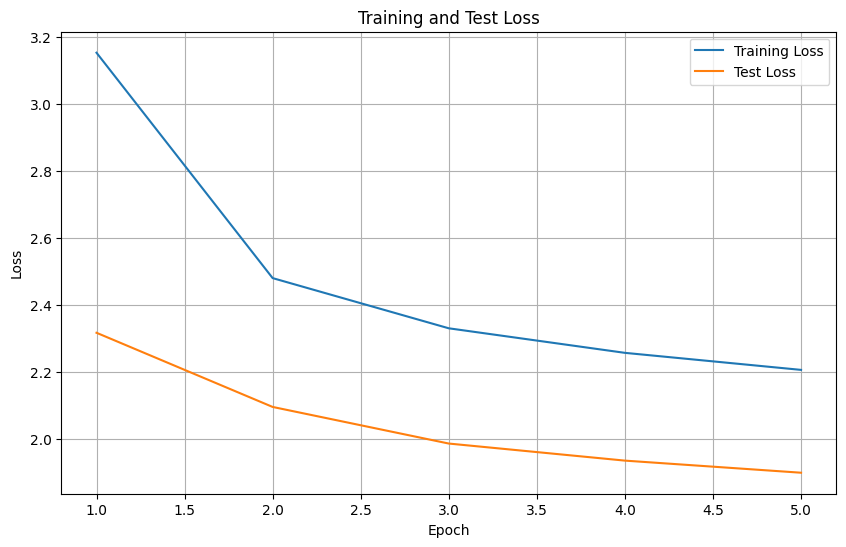

MLP Model saved successfully!


In [73]:
model = BasketballModelMLP(EMBEDDING_DIM, HIDDEN_DIM).to(device)

model_path = 'basketball_player_removal_mlp_model.pt'
if os.path.exists(model_path):
    print(f"Loading existing model from {model_path}")
    model.load_state_dict(torch.load(model_path))
else:
    print("No existing model found. Starting with a new model.")

    train_losses, test_losses = train_model(model, train_dataloader, test_dataloader, EPOCHS, LEARNING_RATE, device)

    plt.figure(figsize=(10, 6))
    plt.plot(range(1, EPOCHS + 1), train_losses, label='Training Loss')
    plt.plot(range(1, EPOCHS + 1), test_losses, label='Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Test Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    torch.save(model.state_dict(), model_path)
    print("MLP Model saved successfully!")

In [74]:
def predict_removed_player(model, season_idx, home_team_idx, away_team_idx, starting_min, home_players, away_players, device, names):
    model.eval()

    season_idx = torch.tensor([season_idx], dtype=torch.int32).to(device)
    home_team_idx = torch.tensor([home_team_idx], dtype=torch.int32).to(device)
    away_team_idx = torch.tensor([away_team_idx], dtype=torch.int32).to(device)
    home_players = torch.tensor([home_players], dtype=torch.int32).to(device)
    away_players = torch.tensor([away_players], dtype=torch.int32).to(device)
    starting_min = torch.tensor([starting_min], dtype=torch.float32).to(device)

    with torch.no_grad():
        logits = model(season_idx, home_team_idx, away_team_idx, starting_min, home_players, away_players)
        probs = F.softmax(logits, dim=1)

        confidence, predicted_idx = torch.max(probs, 1)

        predicted_idx_value = predicted_idx.item()
        predicted_player = names[predicted_idx_value] if predicted_idx_value < len(names) else f"Player_{predicted_idx_value}"

        top3_values, top3_indices = torch.topk(probs, 3, dim=1)
        top3_players = []
        for idx, prob in zip(top3_indices[0], top3_values[0]):
            idx_value = idx.item()
            player_name = names[idx_value] if idx_value < len(names) else f"Player_{idx_value}"
            top3_players.append((player_name, prob.item() * 100))

        all_probs = probs[0].cpu().numpy()

    return predicted_player, confidence.item() * 100, top3_players, all_probs

In [75]:
def random_prediction(model, dataset, games, seasons, teams, names, device):
    random_idx = np.random.randint(0, len(dataset))
    context_tensor, target_tensor = dataset[random_idx]

    game_idx = int(context_tensor[0].item())
    season_idx = int(context_tensor[1].item())
    home_team_idx = int(context_tensor[2].item())
    away_team_idx = int(context_tensor[3].item())
    home_players = context_tensor[4:9].tolist()
    away_players = context_tensor[9:14].tolist()
    starting_min = int(context_tensor[-2].item())
    player_removed_idx = int(target_tensor.item())

    game_str = games[game_idx]
    season_str = seasons[season_idx]
    home_team_str = teams[home_team_idx]
    away_team_str = teams[away_team_idx]
    player_removed_str = names[player_removed_idx]

    home_players_str = []
    away_players_str = []

    for idx in home_players:
        name = names[idx]
        home_players_str.append(name)

    for idx in away_players:
        name = names[idx]
        away_players_str.append(name)

    print(f'Game: {game_str}')
    print(f'Season: {season_str}')
    print(f'Home Team: {home_team_str}')
    print(f'Away Team: {away_team_str}')
    print(f'Starting Minute: {starting_min}')
    print(f'Player Removed: {player_removed_str}')
    print(f'Home Players: {home_players_str}')
    print(f'Away Players: {away_players_str}')
    print("-" * 50)

    predicted_player, confidence, top3_players, all_probs = predict_removed_player(
        model, season_idx, home_team_idx, away_team_idx,
        starting_min, home_players[:4], away_players, device, names
    )

    actual_player_confidence = all_probs[player_removed_idx] * 100
    actual_player_rank = np.where(np.argsort(-all_probs) == player_removed_idx)[0][0] + 1

    print(f'Prediction Results:')
    print(f'Predicted Player: {predicted_player}')
    print(f'Confidence: {confidence:.2f}%')
    print(f'Actual Player: {player_removed_str}')
    print(f'Actual Player\'s Confidence: {actual_player_confidence:.2f}%')
    print(f'Actual Player\'s Rank: {actual_player_rank}')
    print(f'Top 3 Predictions:')
    for i, (player, conf) in enumerate(top3_players):
        print(f'  {i+1}. {player} ({conf:.2f}%)')

    is_correct = predicted_player == player_removed_str
    print(f'Correct Prediction: {"✓" if is_correct else "✗"}')

    return {
        'game': game_str,
        'season': season_str,
        'home_team': home_team_str,
        'away_team': away_team_str,
        'player_removed_actual': player_removed_str,
        'player_removed_predicted': predicted_player,
        'confidence': confidence,
        'actual_player_confidence': actual_player_confidence,
        'actual_player_rank': actual_player_rank,
        'correct': is_correct,
        'top3_players': top3_players
    }

dataset_to_check = test_dataset
random_prediction(model, dataset_to_check, games, seasons, teams, names, device)

Game: 201212050CLE
Season: 2013
Home Team: CLE
Away Team: CHI
Starting Minute: 47
Player Removed: Samardo Samuels
Home Players: ['Daniel Gibson', 'Jeremy Pargo', 'Omri Casspi', 'Tyler Zeller', 'Carlos Boozer']
Away Players: ['Joakim Noah', 'Kirk Hinrich', 'Luol Deng', 'Marco Belinelli', 'Andrea Bargnani']
--------------------------------------------------
Prediction Results:
Predicted Player: Anderson Varejao
Confidence: 20.82%
Actual Player: Samardo Samuels
Actual Player's Confidence: 1.32%
Actual Player's Rank: 16
Top 3 Predictions:
  1. Anderson Varejao (20.82%)
  2. Tristan Thompson (17.74%)
  3. Tyler Zeller (11.68%)
Correct Prediction: ✗


{'game': '201212050CLE',
 'season': 2013,
 'home_team': 'CLE',
 'away_team': 'CHI',
 'player_removed_actual': 'Samardo Samuels',
 'player_removed_predicted': 'Anderson Varejao',
 'confidence': 20.815156400203705,
 'actual_player_confidence': np.float32(1.3199059),
 'actual_player_rank': np.int64(16),
 'correct': False,
 'top3_players': [('Anderson Varejao', 20.815156400203705),
  ('Tristan Thompson', 17.742106318473816),
  ('Tyler Zeller', 11.67534589767456)]}

In [76]:
nba_test_df = pd.read_csv('./data/NBA_test.csv')
nba_test_df

,season,home_team,away_team,starting_min,home_0,home_1,home_2,home_3,home_4,away_0,away_1,away_2,away_3,away_4
0,2007,IND,BOS,18,Danny Granger,Darrell Armstrong,Keith McLeod,Mike Dunleavy,?,Allan Ray,Gerald Green,Kendrick Perkins,Ryan Gomes,Sebastian Telfair
1,2007,HOU,DAL,16,Bonzi Wells,?,Juwan Howard,Luther Head,Tracy McGrady,Austin Croshere,Erick Dampier,Greg Buckner,Jason Terry,Josh Howard
2,2007,SAS,POR,39,Beno Udrih,?,Bruce Bowen,Matt Bonner,Tim Duncan,Brandon Roy,Jamaal Magloire,Jarrett Jack,Juan Dixon,Zach Randolph
3,2007,MIN,BOS,21,?,Kevin Garnett,Randy Foye,Ricky Davis,Trenton Hassell,Al Jefferson,Brian Scalabrine,Delonte West,Paul Pierce,Ryan Gomes
4,2007,MEM,LAL,19,Chucky Atkins,Hakim Warrick,Mike Miller,Rudy Gay,?,Andrew Bynum,Kobe Bryant,Lamar Odom,Luke Walton,Smush Parker
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,2016,BRK,CHO,20,?,Joe Johnson,Thaddeus Young,Wayne Ellington,Willie Reed,Al Jefferson,Courtney Lee,Kemba Walker,Marvin Williams,Nicolas Batum
996,2016,TOR,CHO,21,DeMar DeRozan,DeMarre Carroll,?,Kyle Lowry,Luis Scola,Frank Kaminsky,Jeremy Lamb,Kemba Walker,Marvin Williams,Nicolas Batum
997,2016,DAL,DET,13,David Lee,?,Dirk Nowitzki,J.J. Barea,Raymond Felton,Aron Baynes,Kentavious Caldwell-Pope,Reggie Bullock,Steve Blake,Tobias Harris
998,2016,NOP,ORL,24,Anthony Davis,Eric Gordon,?,Jrue Holiday,Ryan Anderson,C.J. Watson,Evan Fournier,Jason Smith,Nikola Vucevic,Victor Oladipo


In [77]:
nba_test_labels_df = pd.read_csv('./data/NBA_test_labels.csv')
nba_test_labels_df

,removed_value
0,Troy Murphy
1,Chuck Hayes
2,Brent Barry
3,Craig Smith
4,Stromile Swift
...,...
995,Donald Sloan
996,Jonas Valanciunas
997,Devin Harris
998,Ish Smith


In [78]:
home_cols = ['home_0', 'home_1', 'home_2', 'home_3', 'home_4']
away_cols = ['away_0', 'away_1', 'away_2', 'away_3', 'away_4']

In [79]:
rows = []
for i in range(len(nba_test_df)):
    row = nba_test_df.iloc[i]
    season_int = int(row['season'])
    season_idx = seasons.index(season_int)
    home_team_str = str(row['home_team'])
    away_team_str = str(row['away_team'])
    home_team_idx = teams.index(home_team_str)
    away_team_idx = teams.index(away_team_str)
    starting_min = int(row['starting_min'])
    home_players = []
    away_players = []

    for col_name in home_cols:
        name = row[col_name]
        if name == '?':
            continue
        name_idx = names.index(name)
        home_players.append(name_idx)
    home_players.sort()

    for col_name in away_cols:
        name = row[col_name]
        if name == '?':
            continue
        name_idx = names.index(name)
        away_players.append(name_idx)
    away_players.sort()

    row = nba_test_labels_df.iloc[i]
    name = row['removed_value']
    try:
        name_idx = names.index(name)
    except:
        print(f'{name} wasn\'t even in the training data')

    obj = {
        'season': season_idx,
        'home_team': home_team_idx,
        'away_team': away_team_idx,
        'starting_min': starting_min,
        'home_players': home_players,
        'away_players': away_players,
        'player_removed': name_idx,
    }
    rows.append(obj)


nba_test_df_processed = pd.DataFrame(rows)
nba_test_df_processed

Anthony Brown wasn't even in the training data
R.J. Hunter wasn't even in the training data


,season,home_team,away_team,starting_min,home_players,away_players,player_removed
0,0,12,1,18,"[226, 239, 589, 744]","[28, 371, 596, 903, 924]",1025
1,0,11,7,16,"[105, 578, 675, 1009]","[80, 344, 385, 475, 555]",181
2,0,30,28,39,"[91, 127, 718, 993]","[116, 436, 464, 563, 1080]",119
3,0,18,1,21,"[603, 845, 868, 1014]","[14, 124, 264, 824, 903]",199
4,0,15,14,19,"[182, 393, 748, 897]","[52, 618, 636, 672, 947]",970
...,...,...,...,...,...,...,...
995,9,2,5,20,"[517, 988, 1056, 1068]","[14, 196, 594, 715, 784]",297
996,9,32,5,21,"[255, 258, 629, 666]","[358, 493, 594, 715, 784]",535
997,9,7,9,13,"[246, 294, 416, 857]","[78, 600, 858, 962, 999]",284
998,9,22,25,24,"[62, 339, 561, 901]","[132, 351, 474, 789, 1045]",413


In [80]:
import random
random_idx = random.randint(0, len(nba_test_df_processed))
print(f'Analyzing index {random_idx}')
sample_row = nba_test_df_processed.iloc[random_idx]
season_idx = sample_row['season']
home_team_idx = sample_row['home_team']
away_team_idx = sample_row['away_team']
starting_min = sample_row['starting_min']
home_players = sample_row['home_players']
away_players = sample_row['away_players']

home_team_name = teams[home_team_idx]
away_team_name = teams[away_team_idx]
season_year = seasons[season_idx]

print(f'Game Information:')
print(f'Home Team: {home_team_name}')
print(f'Away Team: {away_team_name}')
print(f'Season: {season_year}')
print(f'Starting Minute: {starting_min}')
print('-' * 40)

predicted_player, confidence, top3_players, all_probs = predict_removed_player(
   model, season_idx, home_team_idx, away_team_idx,
   starting_min, home_players[:4], away_players, device, names
)

actual_player_idx = sample_row['player_removed']
actual_player = names[actual_player_idx]

actual_player_confidence = all_probs[actual_player_idx] * 100
sorted_indices = np.argsort(-all_probs)
actual_player_rank = np.where(sorted_indices == actual_player_idx)[0][0] + 1
total_players = len(all_probs)

print(f'Prediction Results:')
print(f'Predicted Player: {predicted_player}')
print(f'Confidence: {confidence:.2f}%')
print(f'Actual Player: {actual_player}')
print(f'Actual Player\'s Confidence: {actual_player_confidence:.2f}%')
print(f'Actual Player\'s Rank: {actual_player_rank} out of {total_players}')

print(f'Top 3 Predictions:')
for i, (player, conf) in enumerate(top3_players):
   print(f'  {i+1}. {player} ({conf:.2f}%)')

is_correct = predicted_player == actual_player
print(f'Correct Prediction: {"✓" if is_correct else "✗"}')

Analyzing index 303
Game Information:
Home Team: MEM
Away Team: DEN
Season: 2010
Starting Minute: 35
----------------------------------------
Prediction Results:
Predicted Player: Hasheem Thabeet
Confidence: 19.10%
Actual Player: Zach Randolph
Actual Player's Confidence: 11.00%
Actual Player's Rank: 3 out of 1084
Top 3 Predictions:
  1. Hasheem Thabeet (19.10%)
  2. Marc Gasol (13.89%)
  3. Zach Randolph (11.00%)
Correct Prediction: ✗


In [81]:
nba_test_labels_df = pd.read_csv('./data/NBA_test_labels.csv')
names_set = set(names)
not_found_names = []
for name in nba_test_labels_df['removed_value'].tolist():
  if name not in names_set:
    not_found_names.append(name)

print(f"Names not found in 'names': {not_found_names}")


Names not found in 'names': ['Anthony Brown', 'R.J. Hunter']


In [82]:
import pandas as pd

matchup_files = [f for f in os.listdir('./data') if f.startswith('matchups-20') and f.endswith('.csv')]

season_match_counts = {}
for file in matchup_files:
  df = pd.read_csv(os.path.join('./data', file))
  season = file.split('-')[1][:4]  # Extract season from filename
  season_match_counts[season] = len(df)

total_matches = sum(season_match_counts.values())
num_seasons = len(season_match_counts)
average_matches = total_matches / num_seasons

print(f'Total Matches: {total_matches}')

print("Matches per Season:")
for season, count in season_match_counts.items():
  print(f"Season {season}: {count} matches")

print(f"\nAverage number of matches over {num_seasons} seasons: {average_matches:.2f}")


Total Matches: 236912
Matches per Season:
Season 2014: 27261 matches
Season 2009: 26407 matches
Season 2012: 21241 matches
Season 2013: 26351 matches
Season 2010: 26344 matches
Season 2007: 27500 matches
Season 2011: 26447 matches
Season 2008: 26593 matches
Season 2015: 28768 matches

Average number of matches over 9 seasons: 26323.56


In [83]:
# prompt: read ./data/mapped_data.csv and output test_df.head()

import pandas as pd

test_df = pd.read_csv('./data/mapped_data.csv')
print(test_df.head())

print(f'{len(test_df)}')


   game  season  home_team  away_team  starting_min  outcome  \
0  9610       8         29         10             0       -1   
1  9610       8         29         10             7       -1   
2  9610       8         29         10             8       -1   
3  9610       8         29         10             9       -1   
4  9610       8         29         10            10       -1   

                home_players               away_players  
0   [88, 241, 256, 476, 897]   [51, 307, 396, 617, 958]  
1   [88, 241, 256, 476, 897]  [307, 355, 396, 617, 958]  
2  [138, 241, 256, 785, 897]   [43, 355, 617, 713, 958]  
3  [138, 241, 256, 277, 785]   [43, 355, 617, 713, 958]  
4  [138, 277, 785, 843, 859]   [43, 355, 617, 713, 958]  
236912


In [84]:
test_2_df = pd.read_csv('./data/mapped_expanded.csv')
len(test_2_df)

test_2_df.head()

,game,season,home_team,away_team,starting_min,outcome,home_players,away_players,player_removed
0,9610,8,29,10,0,-1,"[241, 256, 476, 897]","[51, 307, 396, 617, 958]",88
1,9610,8,29,10,0,-1,"[88, 256, 476, 897]","[51, 307, 396, 617, 958]",241
2,9610,8,29,10,0,-1,"[88, 241, 476, 897]","[51, 307, 396, 617, 958]",256
3,9610,8,29,10,0,-1,"[88, 241, 256, 897]","[51, 307, 396, 617, 958]",476
4,9610,8,29,10,0,-1,"[88, 241, 256, 476]","[51, 307, 396, 617, 958]",897


In [85]:
outcome_1_df = test_2_df[test_2_df['outcome'] == 1]
print(len(outcome_1_df))


440875
